In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
df = pd.read_excel("Superstore_Cleaned.xlsx")

In [88]:
df.shape

(9954, 27)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9954 non-null   int64         
 1   Order ID           9954 non-null   str           
 2   Order Date         9954 non-null   datetime64[us]
 3   Ship Date          9954 non-null   datetime64[us]
 4   Ship Mode          9954 non-null   str           
 5   Customer ID        9954 non-null   str           
 6   Customer Name      9954 non-null   str           
 7   Segment            9954 non-null   str           
 8   Country            9954 non-null   str           
 9   City               9954 non-null   str           
 10  State              9954 non-null   str           
 11  Postal Code        9954 non-null   int64         
 12  Region             9954 non-null   str           
 13  Product ID         9954 non-null   str           
 14  Category           

In [90]:
# Task 1: Monthly Sales Trend
# Create a line chart showing total sales month-wise.
# Write insights:
# Which month has the highest sales?
# Which month has the lowest sales?
# Is there any seasonal pattern in sales?

In [91]:
print(f"date ranges is {df["Order Date"].min()} to {df["Order Date"].max()}")

date ranges is 2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [92]:
monthly_sales = df.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()
monthly_sales = monthly_sales.sort_values(["Order Year", "Order Month"])
monthly_sales["Month_Label"] = (monthly_sales["Order Year"].astype(str) + "-" + monthly_sales["Order Month"].astype(str))
print(monthly_sales)

    Order Year  Order Month        Sales Month_Label
0         2014            1   14236.8950      2014-1
1         2014            2    4519.8920      2014-2
2         2014            3   57198.6410      2014-3
3         2014            4   28166.5130      2014-4
4         2014            5   23648.2870      2014-5
5         2014            6   34454.9676      2014-6
6         2014            7   33798.0790      2014-7
7         2014            8   27892.1285      2014-8
8         2014            9   81414.9708      2014-9
9         2014           10  129521.8010     2014-10
10        2014           11   78576.6527     2014-11
11        2014           12   69797.4105     2014-12
12        2015            1   18174.0756      2015-1
13        2015            2   11308.8290      2015-2
14        2015            3   37512.7076      2015-3
15        2015            4   33869.7465      2015-4
16        2015            5   30131.6865      2015-5
17        2015            6   28533.9660      

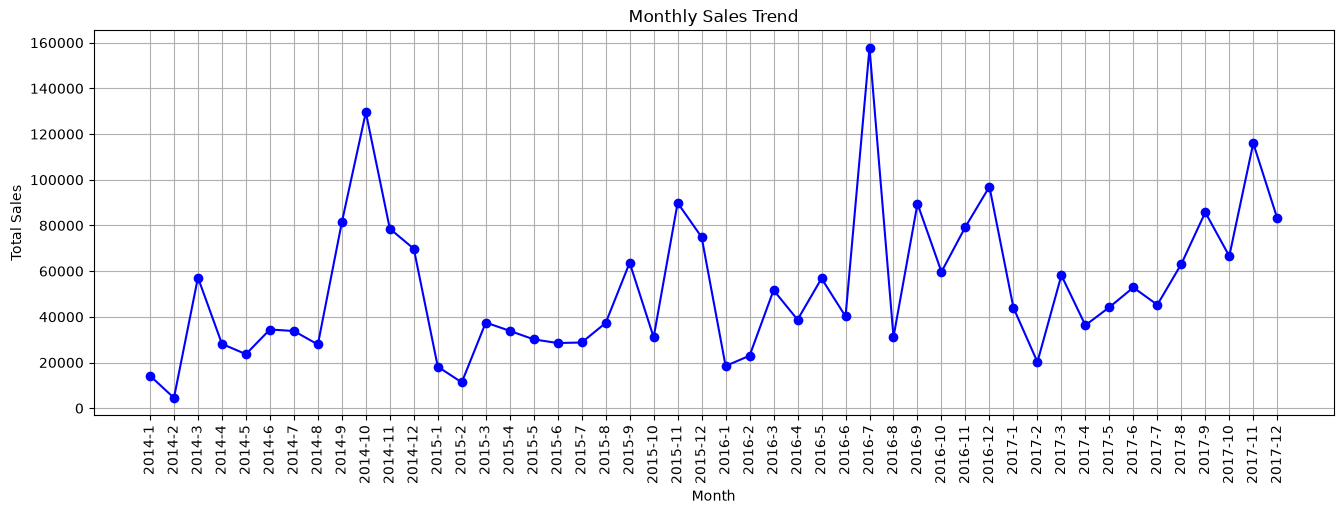

In [93]:
plt.figure(figsize=(16,5))
plt.plot(monthly_sales["Month_Label"],monthly_sales["Sales"],marker="o",color="blue")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

*Highest Sales:*
*November recorded the highest sales, with total sales of approximately ₹3.64 lakh, indicating peak customer demand during this month.*

*Lowest Sales:*
*February had the lowest sales, with total sales of around ₹58,000, suggesting comparatively weaker business activity.*

*Seasonal Pattern:*
*Sales show a clear seasonal trend, with noticeable peaks in July, September–December, especially November and December. In contrast, the beginning of the year (January–February) experiences relatively lower sales, indicating stronger revenue generation during the latter half of the year, likely due to festive and holiday shopping periods.*

In [94]:
sales_cat = df.groupby('Category')['Sales'].sum().reset_index()
sales_cat

,Category,Sales
0,Furniture,872884.5089
1,Office Supplies,732970.2300
2,Technology,921516.9890


C:\Users\HP\AppData\Local\Temp\ipykernel_3520\3478851279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Category", y ="Sales", data = sales_cat , palette = 'pastel', edgecolor = 'black')


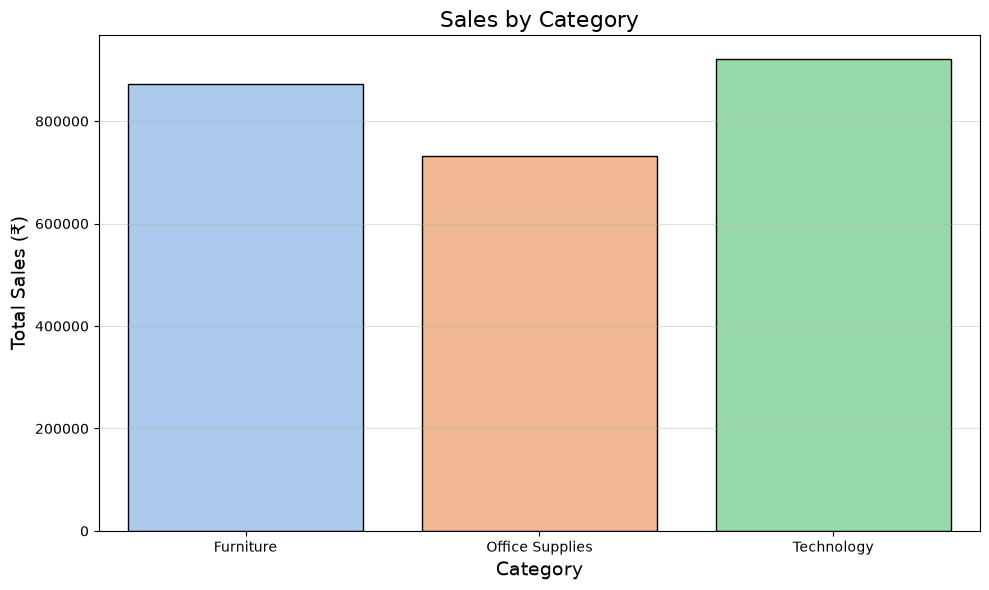

In [95]:
# Task 2: Sales by Category
# Create a bar chart showing total sales by category.
plt.figure(figsize=(10, 6))

sns.barplot(x = "Category", y ="Sales", data = sales_cat , palette = 'pastel', edgecolor = 'black')

plt.xlabel('Category', fontsize=14) 
plt.ylabel('Total Sales (₹)', fontsize=14)
plt.title('Sales by Category', fontsize=16)

plt.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.show()
# Write insights:
# Which category generated the highest sales?
# Which category generated the lowest sales?
# Does high sales always mean high profit?

*Highest Sales: The Technology category generated the highest total sales, indicating strong customer demand for technology products.*

*Lowest Sales: The Office Supplies category generated the lowest total sales among the three categories.*

*High Sales vs. High Profit: High sales do not always result in high profit. A category may have high sales but lower profit due to high discounts, increased costs, or lower profit margins. Therefore, profit should be analyzed separately before making business decisions.*

In [96]:
profit_cat = df.groupby('Category')['Profit'].sum().reset_index()
profit_cat

,Category,Profit
0,Furniture,18179.4889
1,Office Supplies,122816.8196
2,Technology,140863.6819


C:\Users\HP\AppData\Local\Temp\ipykernel_3520\1149562430.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Category", y ="Profit", data = profit_cat ,palette = 'Set2', edgecolor = 'black')


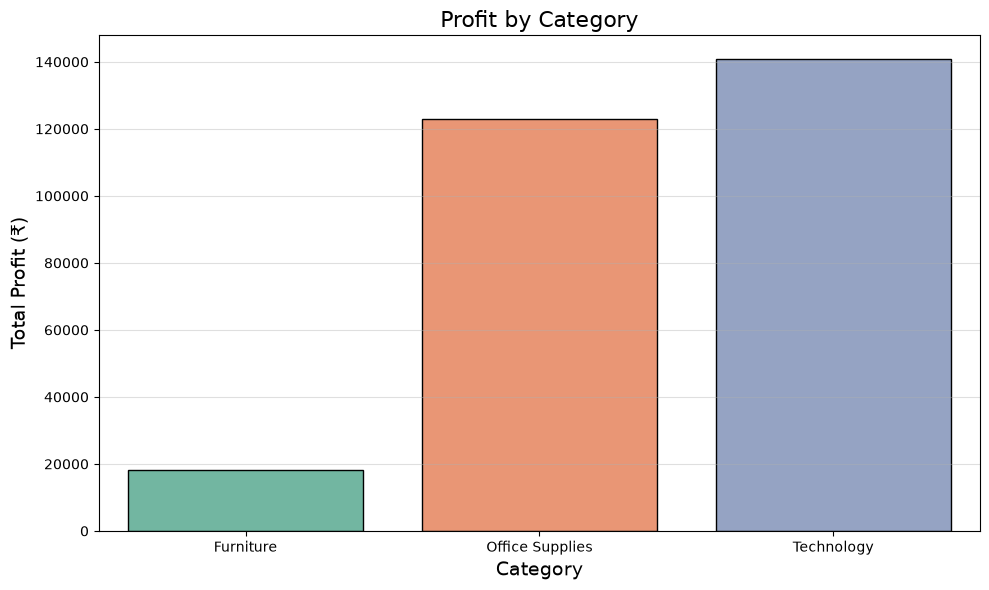

In [97]:
# Task 3: Profit by Category
# Create a bar chart showing total profit by category.
plt.figure(figsize=(10, 6))

sns.barplot(x = "Category", y ="Profit", data = profit_cat ,palette = 'Set2', edgecolor = 'black')

plt.xlabel('Category', fontsize=14)
plt.ylabel('Total Profit (₹)', fontsize=14)
plt.title('Profit by Category', fontsize=16)

plt.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.show()
# Write insights:
# Which category generated the highest profit?
# Which category generated the lowest profit?
# Compare this chart with the sales-by-category chart.

In [98]:
profit_subcat = df.groupby('Sub-Category')['Profit'].sum().reset_index()
profit_subcat


,Sub-Category,Profit
0,Accessories,41797.4636
1,Appliances,18051.3931
2,Art,6510.5500
3,Binders,30863.7847
4,Bookcases,-3459.3964
5,Chairs,26336.9708
6,Copiers,51697.8361
7,Envelopes,6923.8417
8,Fasteners,956.4926
9,Furnishings,12957.3832


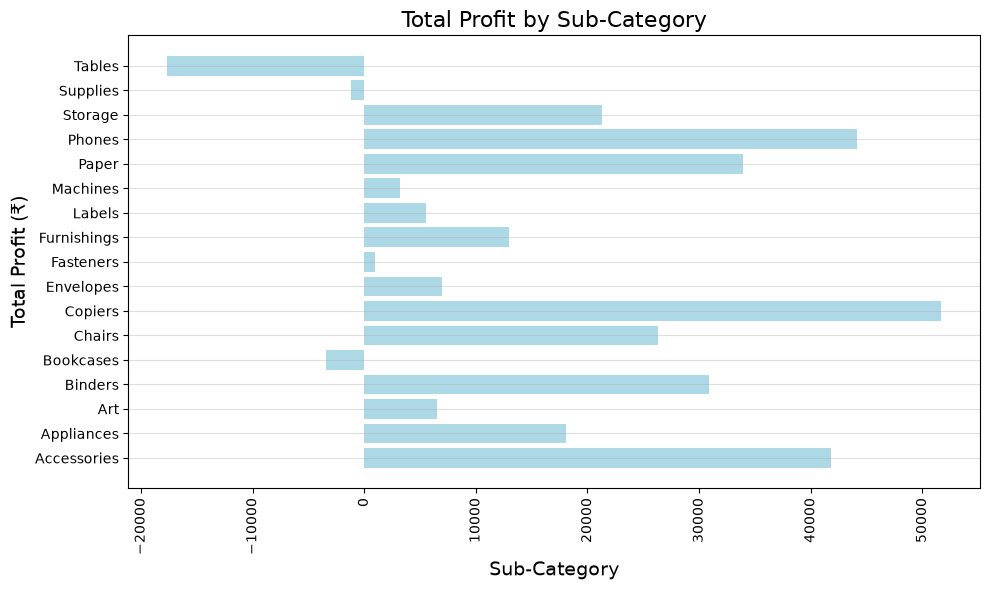

In [99]:
# Task 4: Profit by Sub-Category
# Create a horizontal bar chart showing total profit by sub-category.
plt.figure(figsize=(10, 6))

plt.barh(profit_subcat['Sub-Category'], profit_subcat['Profit'], color = 'lightblue')

plt.xlabel('Sub-Category', fontsize=14)
plt.ylabel('Total Profit (₹)', fontsize=14)
plt.title('Total Profit by Sub-Category', fontsize=16)

plt.grid(axis = 'y', alpha = 0.4)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()


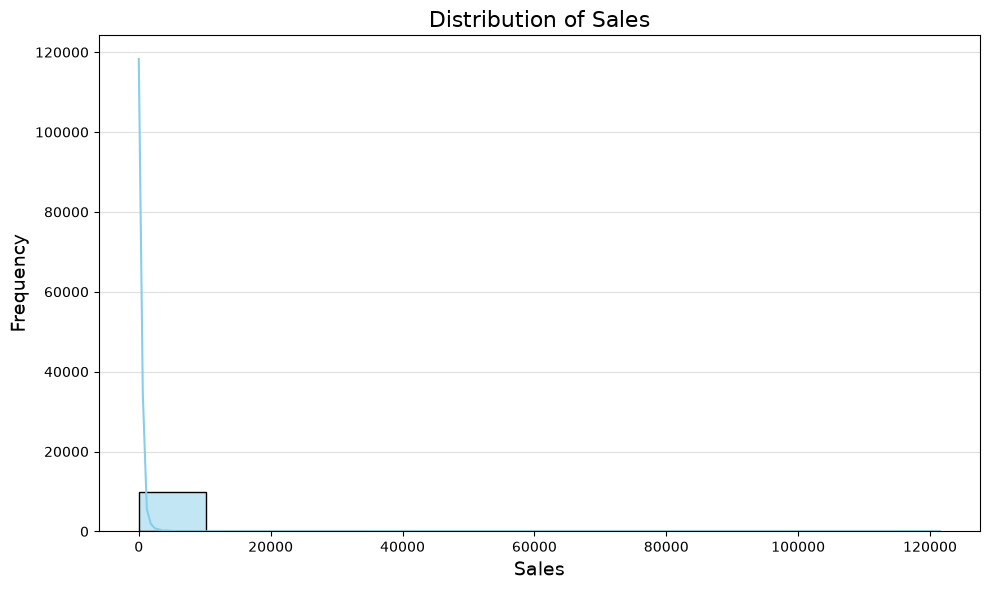

In [113]:
plt.figure(figsize=(10, 6))

sns.histplot(x = "Sales", data = df, bins =12, kde = True, color = "skyblue")
plt.xlabel('Sales', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Sales', fontsize=16)

plt.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.show()

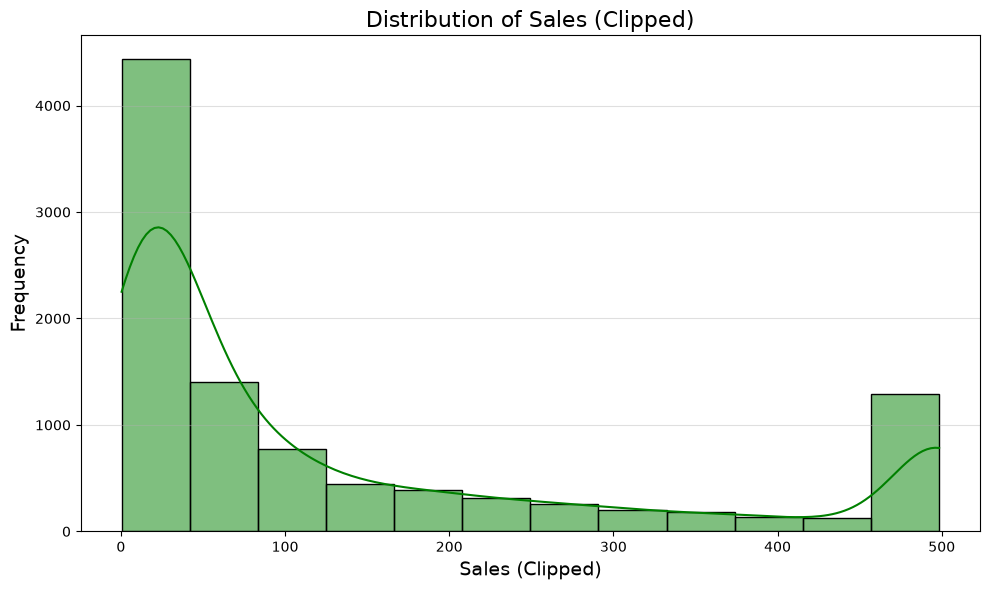

In [116]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 -Q1

upper_bound = Q3 + 1.5 * IQR

df['Sales_clipped'] = df['Sales'].clip(lower= 0, upper = upper_bound)

plt.figure(figsize= (10,6))
sns.histplot(x = "Sales_clipped", data = df, bins =12, kde = True, color = "green", edgecolor = "black")
plt.xlabel('Sales (Clipped)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Sales (Clipped)', fontsize=16)

plt.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.show()


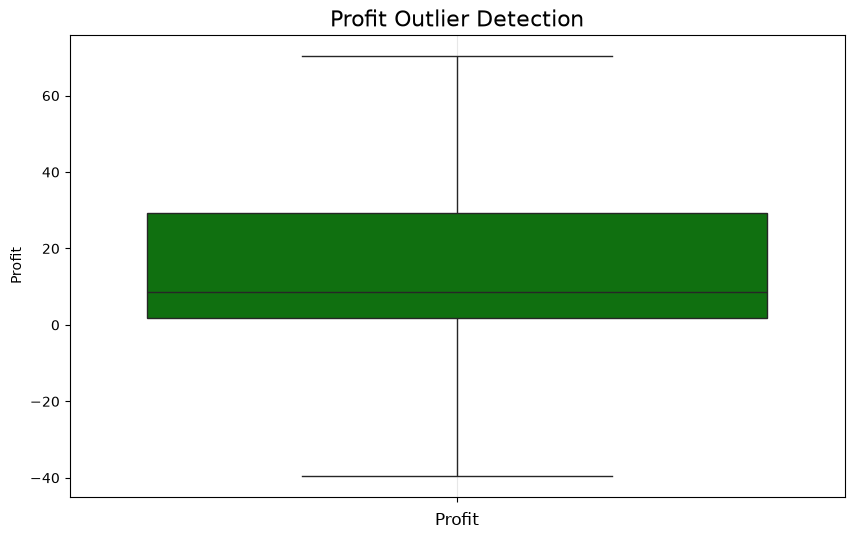

In [110]:
plt.figure(figsize = (10,6))

sns.boxplot(y="Profit", data=df, color = "green", showfliers=False)

plt.xlabel("Profit", fontsize=12)
plt.title("Profit Outlier Detection", fontsize=16)
plt.grid(axis="x", alpha=0.3)

plt.show()

In [165]:
profit_q1=df["Profit"].quantile(0.25)
profit_q3=df["Profit"].quantile(0.75)
profit_iqr=profit_q3-profit_q1

profit_lower=profit_q1-1.5*profit_iqr
profit_upper=profit_q3+1.5*profit_iqr

profit_outliers=df[(df["Profit"]<profit_lower) | (df["Profit"]>profit_upper)]

print("1. There are",len(profit_outliers),"extreme profit/loss values")
print("2. Outliers are important because they show very high profit or loss orders")
print("3. All outliers should not be removed without checking the reason")

1. There are 1874 extreme profit/loss values
2. Outliers are important because they show very high profit or loss orders
3. All outliers should not be removed without checking the reason


C:\Users\HP\AppData\Local\Temp\ipykernel_3520\448817458.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Region", data=df, order= region_order, edgecolor = 'black', palette="pastel")


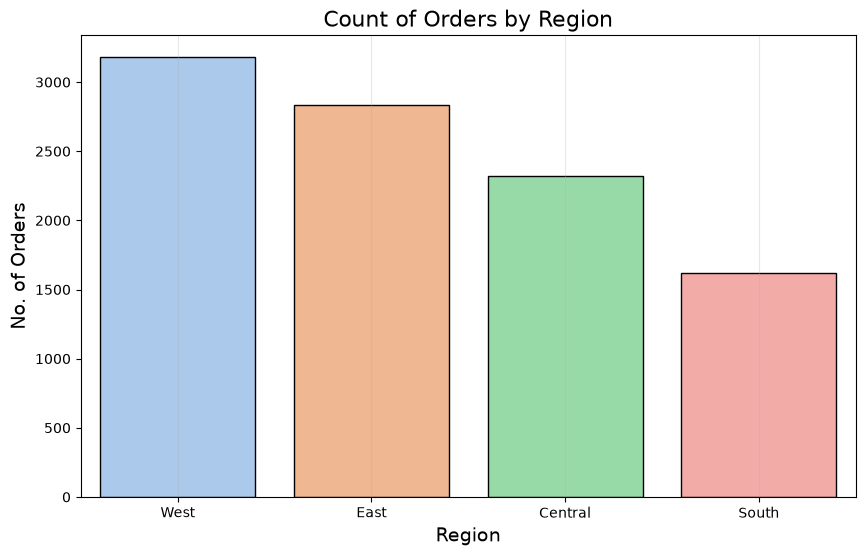

In [164]:
# Task 7: Count of Orders by Region
# Create a countplot showing the number of orders from each region.
region_order = df["Region"].value_counts().index

plt.figure(figsize = (10,6))

sns.countplot(x="Region", data=df, order= region_order, edgecolor = 'black', palette="pastel")

plt.xlabel("Region", fontsize=14)
plt.ylabel("No. of Orders", fontsize=14)
plt.title("Count of Orders by Region", fontsize=16)
plt.grid(axis="x", alpha=0.3)

plt.show()

In [124]:
average = df.groupby('Category')['Profit'].mean().reset_index()
average

,Category,Profit
0,Furniture,8.615872
1,Office Supplies,20.455833
2,Technology,76.556349


C:\Users\HP\AppData\Local\Temp\ipykernel_3520\3184104018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Profit",data=average,palette="pastel")


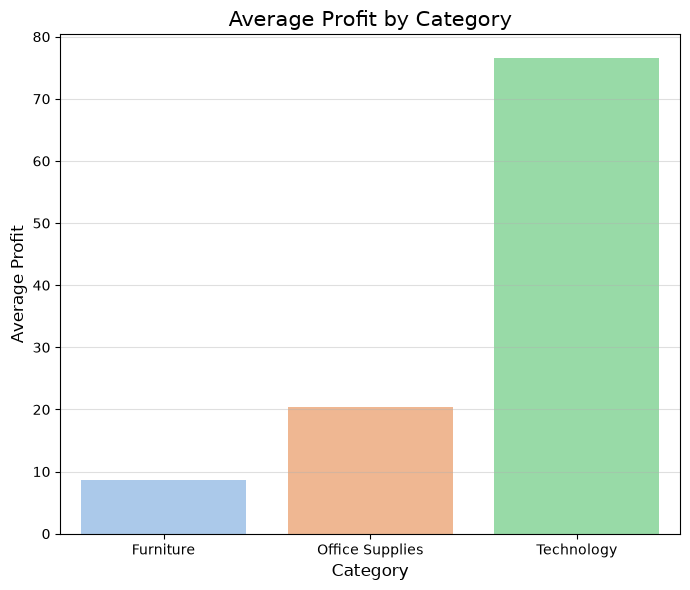

In [131]:
# Task 8: Average Profit by Category
# Write insights:
plt.figure(figsize=(7, 6))

sns.barplot(x="Category",y="Profit",data=average,palette="pastel")

plt.xlabel("Category",fontsize=12)
plt.ylabel("Average Profit",fontsize=12)
plt.title("Average Profit by Category",fontsize=15)

plt.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.show()
# Which category has the highest average profit?
# Which category has the lowest average profit?
# Is high sales always equal to high average profit?


In [160]:
highest_category = average.sort_values(by="Profit", ascending=False).iloc[0]["Category"]
lowest_category = average.sort_values(by="Profit", ascending=True).iloc[0]["Category"]

print("1. Category with highest average profit is", highest_category)
print("2. Category with lowest average profit is", lowest_category)
print("3. High sales is not always equal to high average profit")

1. Category with highest average profit is Technology
2. Category with lowest average profit is Furniture
3. High sales is not always equal to high average profit


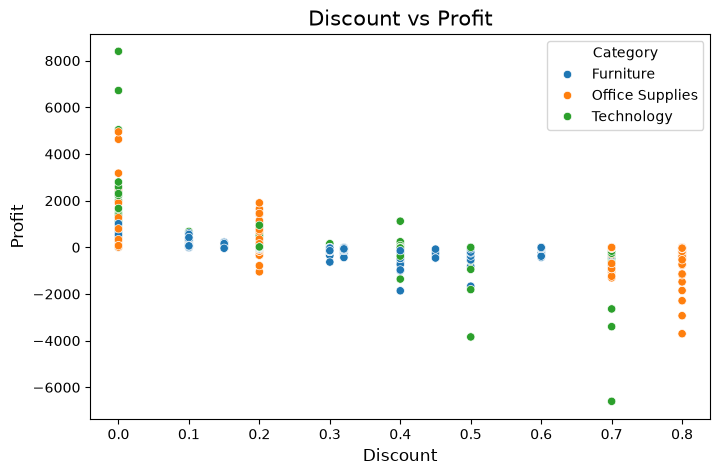

In [158]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Discount",y="Profit",data=df,hue="Category")

plt.xlabel("Discount",fontsize=12)
plt.ylabel("Profit",fontsize=12)
plt.title("Discount vs Profit",fontsize=15)

plt.show()

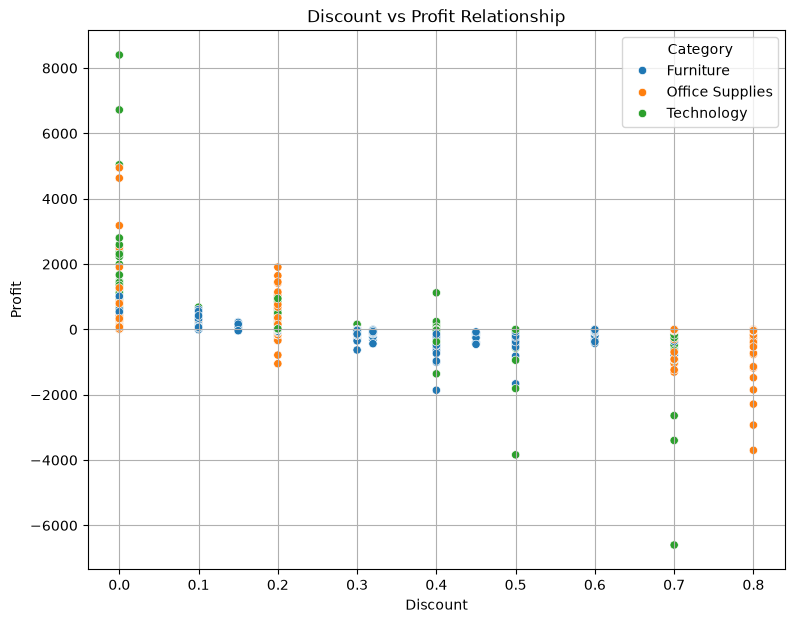

In [136]:
# Task 9: Discount vs Profit Relationship
# Create a scatterplot showing the relationship between Discount and Profit
plt.figure(figsize = (9,7))

sns.scatterplot(x = "Discount", y = "Profit", data = df, hue= "Category")

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)
plt.show()


In [157]:
discount_profit=df["Discount"].corr(df["Profit"])
discount_category=df[df["Discount"]>0].groupby("Category")["Profit"].mean()

print("1. Discount and profit correlation is",round(discount_profit,2))
print("2. Category most affected by discount is",discount_category.idxmin())
print("3. Discount can be an important feature for machine learning")

1. Discount and profit correlation is -0.22
2. Category most affected by discount is Furniture
3. Discount can be an important feature for machine learning


C:\Users\HP\AppData\Local\Temp\ipykernel_3520\127626903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Category",y="Profit",data=df,palette="pastel",showfliers=False)


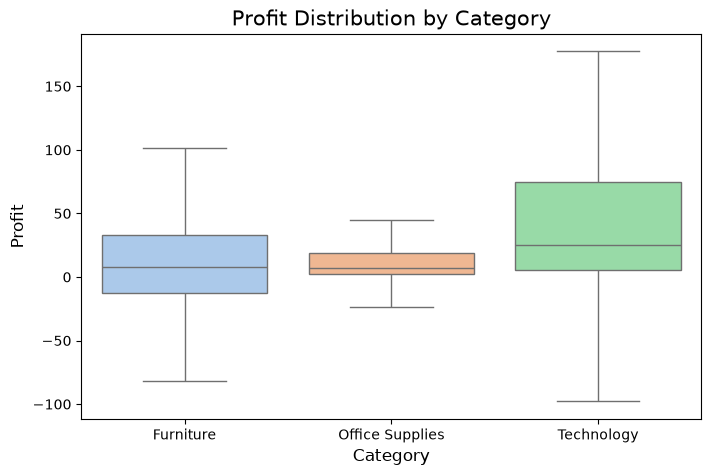

In [137]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Category",y="Profit",data=df,palette="pastel",showfliers=False)

plt.xlabel("Category",fontsize=12)
plt.ylabel("Profit",fontsize=12)
plt.title("Profit Distribution by Category",fontsize=15)

plt.show()

In [156]:
profit_variation=df.groupby("Category")["Profit"].std()
loss_category=df[df["Profit"]<0]["Category"].value_counts()

print("1. Category with more profit variation is",profit_variation.idxmax())
print("2. Category with more loss-making orders is",loss_category.idxmax())
print("3. Yes, there are visible outliers")

1. Category with more profit variation is Technology
2. Category with more loss-making orders is Office Supplies
3. Yes, there are visible outliers


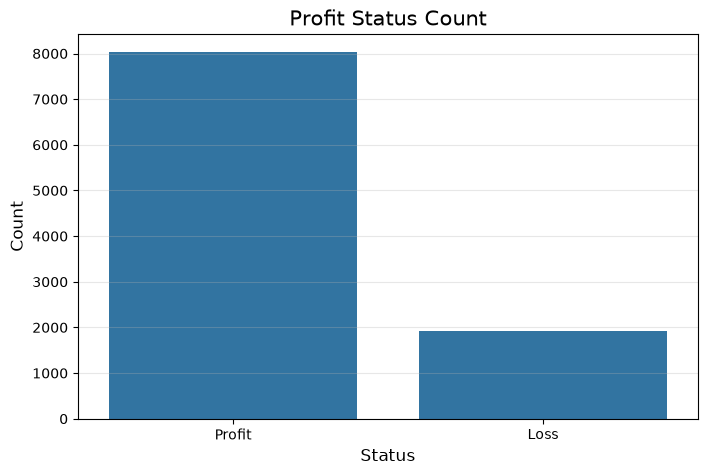

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x = "Profit Status", data=df)

plt.xlabel("Profit Status",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.title("Profit Status Count",fontsize=15)

plt.grid(axis='y', alpha = 0.3)
plt.show()

In [ ]:
profit_status_count=df["Profit Status"].value_counts()
print(profit_status_count)

print("1. There are more",profit_status_count.idxmax(),"orders")
if profit_status_count.max()-profit_status_count.min()>0.20*len(df):
    print("2. The target column is imbalanced")
else:
    print("2. The target column is balanced")
print("3. This is important before classification models because imbalance can affect model performance")

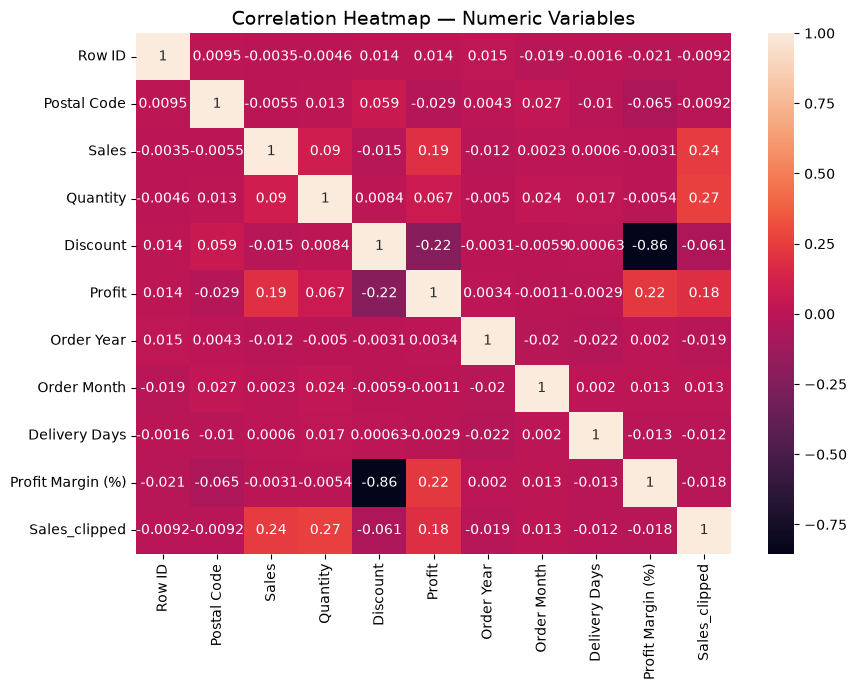

In [155]:
# Task 12: Correlation Heatmap
# Create a heatmap for numerical columns such as:
# Sales
# Quantity
# Discount
# Profit
# DeliveryDays
# ProfitMargin
cols=df.select_dtypes(include="number")
corr=cols.corr()

plt.figure(figsize = (9,7))

sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap — Numeric Variables', fontsize=14)

plt.tight_layout()
plt.show()

In [150]:
print("1. Sales and Profit are positively correlated")
print("2. Discount and Profit are negatively correlated")
print("3. Discount has a negative relation with profit")
print("4. Sales, Quantity, Discount, Delivery Days and Profit Margin can be useful for predicting profit or loss")

1. Sales and Profit are positively correlated
2. Discount and Profit are negatively correlated
3. Discount has a negative relation with profit
4. Sales, Quantity, Discount, Delivery Days and Profit Margin can be useful for predicting profit or loss


In [151]:
highest_sales_category=df.groupby("Category")["Sales"].sum().idxmax()
highest_profit_category=df.groupby("Category")["Profit"].sum().idxmax()
loss_sub_category=df.groupby("Sub-Category")["Profit"].sum().idxmin()
most_orders_region=df["Region"].value_counts().idxmax()

sales_q1=df["Sales"].quantile(0.25)
sales_q3=df["Sales"].quantile(0.75)
sales_iqr=sales_q3-sales_q1
sales_lower=sales_q1-1.5*sales_iqr
sales_upper=sales_q3+1.5*sales_iqr
sales_outliers=df[(df["Sales"]<sales_lower) | (df["Sales"]>sales_upper)]

print("1. Highest sales category is",highest_sales_category)
print("2. Highest profit category is",highest_profit_category)
print("3. Loss-making sub-category is",loss_sub_category)
print("4. Region with most orders is",most_orders_region)
print("5. Discount has negative effect on profit")
print("6. There are",len(sales_outliers),"sales outliers")
print("7. Data can be used for profit/loss prediction")
print("8. Useful ML columns are Sales, Quantity, Discount, Delivery Days and Profit Margin")

1. Highest sales category is Technology
2. Highest profit category is Technology
3. Loss-making sub-category is Tables
4. Region with most orders is West
5. Discount has negative effect on profit
6. There are 1162 sales outliers
7. Data can be used for profit/loss prediction
8. Useful ML columns are Sales, Quantity, Discount, Delivery Days and Profit Margin


In [152]:
print("1. Superstore data shows sales, profit and discount patterns clearly")
print("2. Highest sales category is",highest_sales_category)
print("3. Highest profit category is",highest_profit_category)
print("4. The main loss-making sub-category is",loss_sub_category)
print("5. Discount reduces profit in many orders")
print("6. Profit and sales have outliers, so they should be checked before modelling")
print("7. Visualization helps us understand trends, losses and unusual values")
print("8. Profit Status can be used as target column for classification")
print("9. Sales, Quantity, Discount, Delivery Days and Profit Margin can help in machine learning")

1. Superstore data shows sales, profit and discount patterns clearly
2. Highest sales category is Technology
3. Highest profit category is Technology
4. The main loss-making sub-category is Tables
5. Discount reduces profit in many orders
6. Profit and sales have outliers, so they should be checked before modelling
7. Visualization helps us understand trends, losses and unusual values
8. Profit Status can be used as target column for classification
9. Sales, Quantity, Discount, Delivery Days and Profit Margin can help in machine learning


In [148]:
category_comparison=df.groupby("Category")[["Sales","Profit"]].sum().reset_index()
print(category_comparison)

          Category        Sales       Profit
0        Furniture  872884.5089   18179.4889
1  Office Supplies  732970.2300  122816.8196
2       Technology  921516.9890  140863.6819


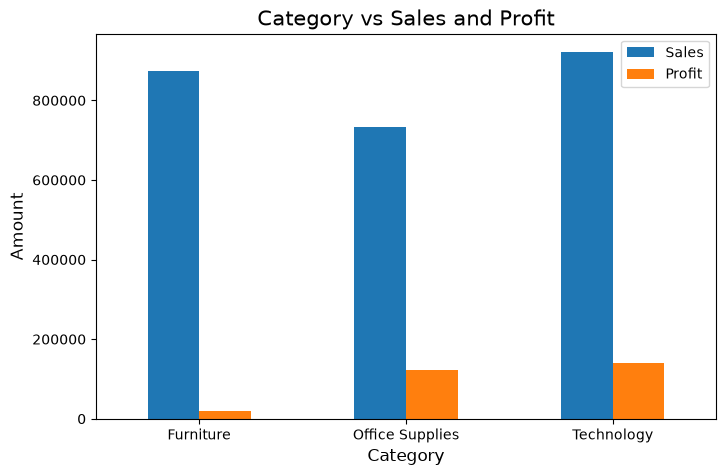

In [149]:
category_comparison.plot(x="Category",y=["Sales","Profit"],kind="bar",figsize=(8,5))

plt.xlabel("Category",fontsize=12)
plt.ylabel("Amount",fontsize=12)
plt.title("Category vs Sales and Profit",fontsize=15)
plt.xticks(rotation=0)

plt.show()